In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import yaml
from scipy.stats import wasserstein_distance
import joblib
import seaborn as sns

selection = "ATLAS"
sample_path = f"Models_Extrapolation_{selection}_ver2/samples"
dataset_path = f"Final_Dataset_{selection}"
SCALER_PATH = f"Final_Dataset_{selection}/minmax_scaler.joblib"
N_ENSEMBLE = 10
scaler = joblib.load(SCALER_PATH)

context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

NOM_WEIGHT_COL = "final_weight"
RW_WEIGHT_COL = "rw_median_weights"
GEN_WEIGHT_COL = "total_weight"

w1_sr_results = {
    "nom": {},
    "rw": {},
    "gen": {}
}

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def transform(df, scale=True):
    # 1. Create a copy immediately so the original remains untouched
    df_transformed = df.copy()
    
    # Order of the variables 
    features_to_scale = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    # 2. Apply transformations to the COPY
    if scale:
        df_transformed.loc[:, features_to_scale] = scaler.transform(df_transformed[features_to_scale].values).astype('float32')
    else:
        df_transformed.loc[:, features_to_scale] = scaler.inverse_transform(df_transformed[features_to_scale].values).astype('float32')
        
    # 3. Return the modified copy
    return df_transformed

In [ ]:
data_sr_events = pd.read_parquet(f"{dataset_path}/DATA_SR_clean.parquet")

# Load Reweight Events
mc_sr_reweight_events = pd.read_parquet(f"{sample_path}/MC_SR_reweighted.parquet")
nominal_w = mc_sr_reweight_events["final_weight"].values
rw_ensemble_weights = [mc_sr_reweight_events[f'reweight_weights_ens{i}'].values for i in range(N_ENSEMBLE)]
rw_median = np.median(rw_ensemble_weights, axis=0)
mc_sr_reweight_events["rw_median_weights"] = nominal_w * rw_median
# Load Generate Events

mc_sr_generate_dfs = []
for i in range(N_ENSEMBLE):
    df = pd.read_parquet(f"{sample_path}/MC_SR_Generate_ens{i}.parquet")
    df['total_weight'] = df['total_weight'] / 10
    
    mc_sr_generate_dfs.append(df)

df_mc_gen = pd.concat(mc_sr_generate_dfs, ignore_index=True)

print(f"Loaded {len(data_sr_events)} Data events")
print(f"Loaded {len(mc_sr_reweight_events)} Reweight events")
print(f"Loaded {len(df_mc_gen)} Generate events")

Loaded 188757 Data events
Loaded 528846 Reweight events
Loaded 528846 Generate events


### Check Background Modelling

In [16]:
def check_unphysical(df, name):
    print('='*20, f"Checking {name} for unphysical events", '='*20)
    print("Events with Missing Energy less than 0:", (df['met_recalc_pt'] < 0).sum() + (df['met_recalc_pt'] > 13_000).sum())
    print("Events with HT less than 0:", (df['ht'] < 0).sum() + (df['ht'] > 13_000).sum())
    print("Events with mjj less than 0:", (df['mjj'] < 0).sum() + (df['mjj'] > 13_000).sum())
    for i in ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']:
        print(f"Events with unphysical N-subjettiness ratio {i}:", ((df[i] < 0).sum() + (df[i] > 1).sum()))

def filter_and_renormalize(df, weight_col=None, name="GENERATE"):
    """
    Removes unphysical events from a DataFrame and renormalizes the weights 
    to preserve the total expected yield.
    """
    print('='*20, f"Filtering {name}", '='*20)
    
    # 1. Store the original total yield (sum of weights)

    original_yield = df[weight_col].sum()
    
    # 2. Build a boolean mask where True means the event is physically valid
    mask = (df['met_recalc_pt'] >= 0) & (df['met_recalc_pt'] <= 13_000) &\
           (df['ht'] >= 0) & (df['ht'] <= 13_000) & \
           (df['mjj'] >= 0) & (df['mjj'] <= 13_000)
    
    for tau in ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']:
        mask = mask & (df[tau] >= 0) & (df[tau] <= 1)
        
    # 3. Apply the mask to drop unphysical events
    df_clean = df[mask].copy()
    events_dropped = len(df) - len(df_clean)
    drop_percentage = (events_dropped / len(df)) * 100
    
    print(f"Total events generated: {len(df)}")
    print(f"Events dropped: {events_dropped} ({drop_percentage:.2f}%)")
    
    # 4. Renormalize the weights of the surviving events

    new_yield_before_scaling = df_clean[weight_col].sum()
    
    # Scale factor = Original Yield / Yield of surviving events
    scale_factor = original_yield / new_yield_before_scaling
    df_clean[weight_col] = df_clean[weight_col] * scale_factor
    
    print(f"Original background yield: {original_yield:.2f}")
    print(f"Yield after cuts (before scaling): {new_yield_before_scaling:.2f}")
    print(f"Applied scale factor: {scale_factor:.4f}")
    print(f"Final normalized yield: {df_clean[weight_col].sum():.2f}")
        
    return df_clean

def signed_wasserstein_distance(u_values, v_values, u_weights, v_weights):
    """
    Computes the 1D Wasserstein distance allowing for negative weights.
    """
    # 1. Sort the values and their corresponding weights
    u_sorter = np.argsort(u_values)
    v_sorter = np.argsort(v_values)
    
    u_val_sorted = np.asarray(u_values)[u_sorter]
    v_val_sorted = np.asarray(v_values)[v_sorter]
    u_wt_sorted = np.asarray(u_weights)[u_sorter]
    v_wt_sorted = np.asarray(v_weights)[v_sorter]

    # 2. Combine all unique values to create the integration grid
    all_values = np.concatenate((u_val_sorted, v_val_sorted))
    all_values.sort(kind='mergesort')

    # 3. Compute deltas (dx for the integral)
    deltas = np.diff(all_values)

    # 4. Find the positions to evaluate the CDFs
    u_cdf_indices = np.searchsorted(u_val_sorted, all_values[:-1], side='right')
    v_cdf_indices = np.searchsorted(v_val_sorted, all_values[:-1], side='right')

    # 5. Compute the empirical CDFs (normalized by the total sum of weights)
    u_cumweights = np.concatenate(([0], np.cumsum(u_wt_sorted)))
    v_cumweights = np.concatenate(([0], np.cumsum(v_wt_sorted)))

    # Prevent division by zero if weights sum perfectly to 0
    u_total = u_cumweights[-1]
    v_total = v_cumweights[-1]
    if u_total == 0 or v_total == 0:
        raise ValueError("Total sum of weights cannot be zero.")

    u_cdf = u_cumweights[u_cdf_indices] / u_total
    v_cdf = v_cumweights[v_cdf_indices] / v_total

    # 6. Compute the integral of the absolute difference
    return np.sum(np.abs(u_cdf - v_cdf) * deltas)


In [17]:
df_data_unscaled = transform(data_sr_events, scale=False)
df_mc_rw_unscaled = transform(mc_sr_reweight_events, scale= False)
df_mc_gen_unscaled = transform(df_mc_gen, scale=False)

check_unphysical(df_data_unscaled, "DATA")
check_unphysical(df_mc_rw_unscaled, "REWEIGHT")
check_unphysical(df_mc_gen_unscaled, "GENERATE")

df_mc_rw_clean = filter_and_renormalize(df_mc_rw_unscaled, RW_WEIGHT_COL, "REWEIGHT")
df_mc_gen_clean = filter_and_renormalize(df_mc_gen_unscaled, GEN_WEIGHT_COL, "GENERATE")

df_mc_rw_scoring = transform(df_mc_rw_clean, scale=True)
df_mc_gen_scoring = transform(df_mc_gen_clean, scale=True)

==================== Checking DATA for unphysical events ====================
Events with Missing Energy less than 0: 0
Events with HT less than 0: 0
Events with mjj less than 0: 0
Events with unphysical N-subjettiness ratio ljet1_tau21: 0
Events with unphysical N-subjettiness ratio ljet1_tau32: 0
Events with unphysical N-subjettiness ratio ljet2_tau21: 0
Events with unphysical N-subjettiness ratio ljet2_tau32: 0
==================== Checking REWEIGHT for unphysical events ====================
Events with Missing Energy less than 0: 0
Events with HT less than 0: 0
Events with mjj less than 0: 0
Events with unphysical N-subjettiness ratio ljet1_tau21: 0
Events with unphysical N-subjettiness ratio ljet1_tau32: 0
Events with unphysical N-subjettiness ratio ljet2_tau21: 0
Events with unphysical N-subjettiness ratio ljet2_tau32: 0
==================== Checking GENERATE for unphysical events ====================
Events with Missing Energy less than 0: 0
Events with HT less than 0: 0
Events w

Data events shape: (188757, 8)
Reweighted events shape: (528846, 41)
Generated events shapes: (5261113, 9)
 == Check W1 ==
Data W1: 0.0


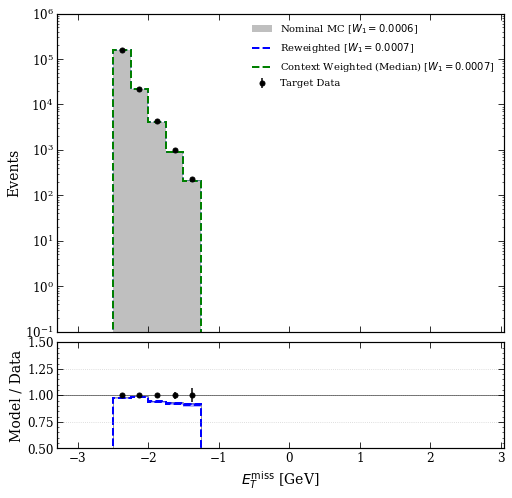

 == Check W1 ==
Data W1: 0.0


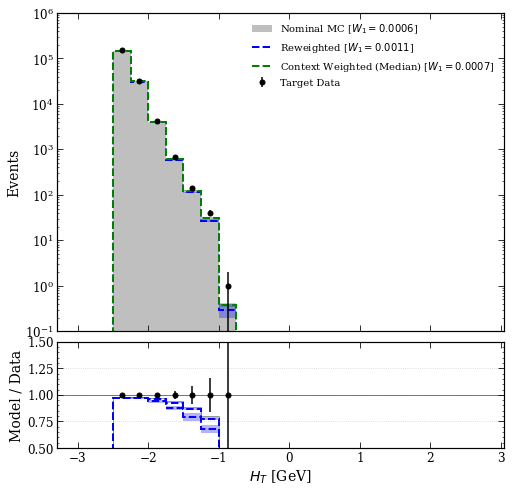

 == Check W1 ==
Data W1: 0.0


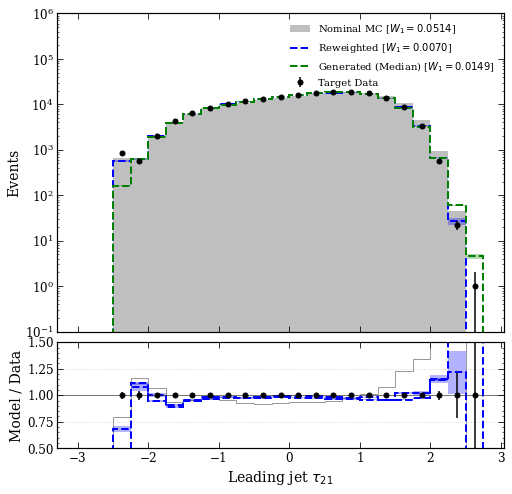

 == Check W1 ==
Data W1: 0.0


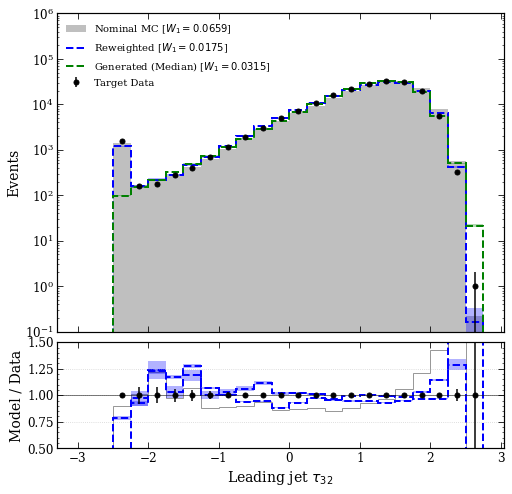

 == Check W1 ==
Data W1: 0.0


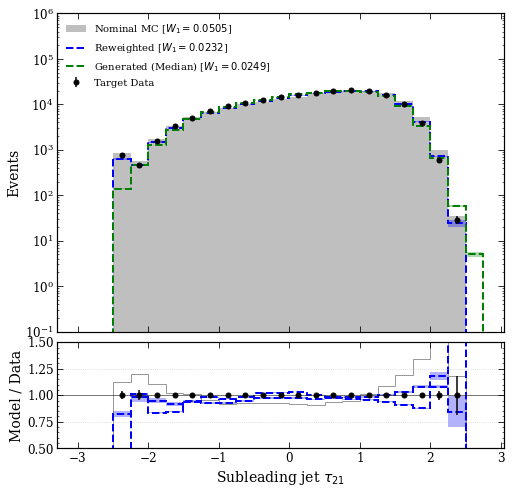

 == Check W1 ==
Data W1: 0.0


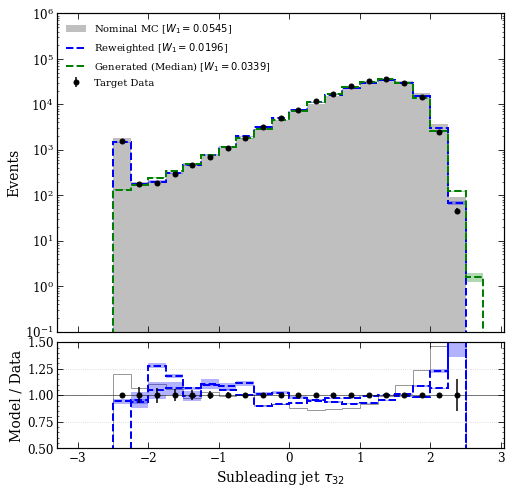

 == Check W1 ==
Data W1: 0.0


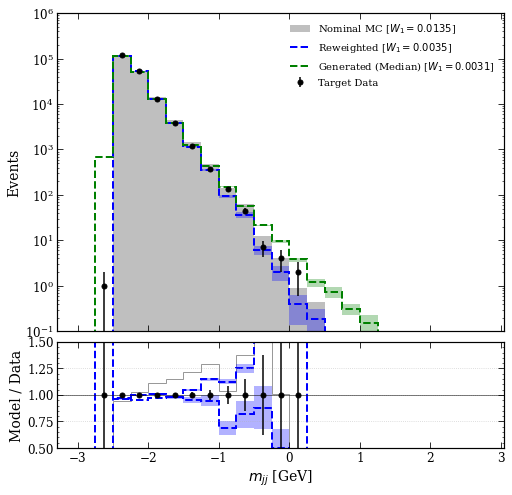

In [ ]:
def plot_context_events(data_events, reweight_events, generate_events):
    print(f"Data events shape: {data_events.shape}")
    print(f"Reweighted events shape: {reweight_events.shape}")
    print(f"Generated events shapes: {generate_events.shape}")

    bins = np.arange(-3.0, 3.0, 0.25)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    for var in context_vars + features_vars:
        # Create a figure with two vertically stacked panels
        fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(8, 8), 
            gridspec_kw={'height_ratios': [3, 1]}, 
            sharex=True
        )
        
        # Remove horizontal space between axes
        fig.subplots_adjust(hspace=0.05)

        # ==========================================
        # TARGET DATA (Calculated once for both panels)
        # ==========================================
        data_arr = data_events[var].to_numpy()
        w_data = np.ones(len(data_events))
        counts_data, _ = np.histogram(data_arr, bins=bins)
        data_errors = np.sqrt(counts_data)
        std_data = np.std(data_arr)
        w1_data = signed_wasserstein_distance(data_events[var], data_events[var], w_data, w_data)

        print(" == Check W1 ==")
        print("Data W1:", w1_data)
        
        # Top panel: Data
        ax1.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Target Data', zorder=10, capsize=0, markersize=5)

        # Bottom panel: Data reference at 1.0
        # Safe division to get fractional errors for the ratio plot
        valid = counts_data > 0
        data_ratio_err = np.zeros_like(counts_data, dtype=float)
        data_ratio_err[valid] = data_errors[valid] / counts_data[valid]
        
        ax2.errorbar(bin_centers[valid], np.ones_like(counts_data[valid]), yerr=data_ratio_err[valid], fmt='ko', zorder=10, capsize=0, markersize=5)
        ax2.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)

        # ==========================================
        # NOMINAL MC
        # ==========================================
        mc_nom = reweight_events[var].to_numpy()
        w_nom = reweight_events['final_weight'].values
        
        counts_nom, _ = np.histogram(mc_nom, bins=bins, weights=w_nom)
        w1_nom = signed_wasserstein_distance(data_arr, mc_nom, w_data, w_nom)
        
        ax1.stairs(counts_nom, bins, fill=True, color="grey", alpha=0.5, label=f'Nominal MC [$W_1 = {w1_nom:.4f}$]')
        
        # Nominal ratio
        ratio_nom = np.divide(counts_nom, counts_data, out=np.full_like(counts_nom, np.nan, dtype=float), where=valid)
        ax2.stairs(ratio_nom, bins, color="grey", alpha=0.8)

        # ==========================================
        # REWEIGHT EVENTS
        # ==========================================
        mc_rw = reweight_events[var].to_numpy()
        w_rw = reweight_events[RW_WEIGHT_COL].values
        rw_binned, _ = np.histogram(mc_rw, bins=bins, weights=w_rw)
            
        rw_variance, _ = np.histogram(mc_rw, bins=bins, weights=w_rw**2)
        rw_error = np.sqrt(rw_variance)

        rw_lower = rw_binned - rw_error
        rw_upper = rw_binned + rw_error

        w1_rw = signed_wasserstein_distance(data_arr, mc_rw, w_data, w_rw)
        # Top panel
        ax1.stairs(rw_binned, bins, color="blue", linewidth=2, linestyle='--', label=f'Reweighted [$W_1 = {w1_rw:.4f}$]')
        ax1.stairs(rw_upper, bins, baseline=rw_lower, fill=True, color='blue', alpha=0.3)

        # Bottom panel
        rw_ratio = np.divide(rw_binned, counts_data, out=np.full_like(rw_binned, np.nan, dtype=float), where=valid)
        rw_ratio_low = np.divide(rw_lower, counts_data, out=np.full_like(rw_lower, np.nan, dtype=float), where=valid)
        rw_ratio_up = np.divide(rw_upper, counts_data, out=np.full_like(rw_upper, np.nan, dtype=float), where=valid)

        ax2.stairs(rw_ratio, bins, color="blue", linewidth=2, linestyle='--')
        ax2.stairs(rw_ratio_up, bins, baseline=rw_ratio_low, fill=True, color='blue', alpha=0.3)
        # ==========================================
        # GENERATE EVENTS
        # ==========================================
        mc_gen = generate_events[var].to_numpy()
        w_gen = generate_events[GEN_WEIGHT_COL].values
        gen_binned, _ = np.histogram(mc_gen, bins=bins, weights=w_gen)

        gen_variance, _ = np.histogram(mc_gen, bins=bins, weights=w_gen**2)
        gen_err = np.sqrt(gen_variance)

        gen_lower = gen_binned - gen_err
        gen_upper = gen_binned + gen_err

        w1_cw = signed_wasserstein_distance(data_arr, mc_gen, w_data, w_gen)
        # Top panel
        if var in context_vars:
            label_gen = 'Context Weighted (Median)'
        else:
            label_gen = 'Generated (Median)'

        ax1.stairs(gen_binned, bins, color='green', linewidth=2, linestyle = '--', label = f"{label_gen} [$W_1 = {w1_cw:.4f}$]")
        ax1.stairs(gen_upper, bins, baseline=gen_lower, fill=True, color ='green', alpha = 0.3)

        # Bottom panel
        gen_ratio = np.divide(gen_binned, counts_data, out=np.full_like(gen_binned, np.nan, dtype=float), where=valid)
        gen_ratio_low = np.divide(gen_lower, counts_data, out=np.full_like(gen_lower, np.nan, dtype=float), where=valid)
        gen_ratio_up = np.divide(gen_upper, counts_data, out=np.full_like(gen_upper, np.nan, dtype=float), where=valid)

        ax2.stairs(gen_ratio, bins, color = 'blue', linewidth=2, linestyle='--')
        ax2.stairs(gen_ratio_up, bins, baseline=gen_ratio_low, fill=True, color='blue', alpha=0.3)

        # ==========================================
        # PLOT FORMATTING
        # ==========================================
        # Top Panel
        ax1.set_yscale('log')
        ax1.set_ylim(0.1, 1e6)
        ax1.set_ylabel('Events')
        ax1.legend(frameon=False)
        ax1.tick_params(axis='x', which='both', bottom=True, top=True, labelbottom=False)

        # Bottom Panel (Ratio)
        ax2.set_ylabel('Model / Data')
        # Adjust these limits based on how wild your ratios get. 0.5 to 1.5 is standard.
        ax2.set_ylim(0.5, 1.5) 
        ax2.set_xlabel(pretty_labels.get(var, var))
        ax2.tick_params(axis='x', which='both', bottom=True, top=True)
        ax2.grid(True, axis='y', linestyle=':', alpha=0.6)
        w1_sr_results['nom'][var] = w1_nom
        w1_sr_results['rw'][var] = w1_rw
        w1_sr_results['gen'][var] = w1_cw
        plt.show()
plot_context_events(data_sr_events, df_mc_rw_scoring, df_mc_gen_scoring)

In [20]:
df_w1_sr_results = pd.DataFrame.from_dict(w1_sr_results, orient='index')
df_w1_sr_results.to_csv("Results/w1_sr_results.csv")

In [9]:
def get_weighted_corr(df, features, weight_col=None):
    """
    Computes a weighted correlation matrix supporting negative weights.
    """
    X = df[features].values
    w = df[weight_col].values if weight_col else np.ones(len(df))
    
    sum_w = np.sum(w)
    if sum_w == 0:
        raise ValueError("Total sum of weights cannot be exactly zero.")
        
    # 1. Compute weighted means
    # w[:, None] reshapes (N,) to (N, 1) so it broadcasts across features
    mean = np.sum(X * w[:, None], axis=0) / sum_w
    
    # 2. Mean-center the features
    X_centered = X - mean
    
    # 3. Compute the weighted covariance matrix 
    # (w * X_centered.T) multiplies each row by its weight before the dot product
    cov_matrix = np.dot(w * X_centered.T, X_centered) / sum_w
    
    # 4. Convert covariance to correlation matrix: R_ij = Cov_ij / sqrt(Cov_ii * Cov_jj)
    std_devs = np.sqrt(np.diag(cov_matrix))
    
    # Suppress warnings for potential division by zero (e.g., zero variance features)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_matrix = cov_matrix / np.outer(std_devs, std_devs)
        # Clean up any NaNs caused by dividing by zero
        corr_matrix[np.isnan(corr_matrix)] = 0.0
        
    return pd.DataFrame(corr_matrix, index=features, columns=features)

def evaluate_correlations(df_data, df_mc_gen, features, weight_col):
    # 1. Compute matrices
    corr_data = get_weighted_corr(df_data, features)
    corr_gen = get_weighted_corr(df_mc_gen, features, weight_col)
    
    # 2. Compute Difference Matrix
    delta_corr = corr_data - corr_gen
    
    # 3. Calculate Quantitative Metric (MAE of off-diagonal elements)
    # We subtract the identity matrix to ignore the self-correlations (which are always exactly 1)
    np_delta = delta_corr.values
    off_diagonal_mask = ~np.eye(np_delta.shape[0], dtype=bool)
    mae_diff = np.mean(np.abs(np_delta[off_diagonal_mask]))
    
    print("=== Joint Distribution Validation ===")
    print(f"Mean Absolute Error of Correlations: {mae_diff:.4f}")
    if mae_diff < 0.05:
        print("Conclusion: Excellent structural fidelity.")
    elif mae_diff < 0.10:
        print("Conclusion: Minor correlation degradation, generally acceptable.")
    else:
        print("Conclusion: WARNING - Severe relationship breakdown detected.")
    
    # 4. Plot Heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Common settings for the standard correlation plots
    cmap_std = sns.diverging_palette(220, 20, as_cmap=True)
    
    sns.heatmap(corr_data, annot=True, fmt=".2f", cmap=cmap_std, vmin=-1, vmax=1, 
                ax=axes[0], cbar_kws={'label': 'Pearson Correlation'})
    axes[0].set_title("Data (Ground Truth)")
    
    sns.heatmap(corr_gen, annot=True, fmt=".2f", cmap=cmap_std, vmin=-1, vmax=1, 
                ax=axes[1], cbar_kws={'label': 'Pearson Correlation'})
    axes[1].set_title("MC Generated")
    
    # The difference plot uses a colormap centered strictly on zero to highlight errors
    sns.heatmap(delta_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-0.3, vmax=0.3, 
                ax=axes[2], cbar_kws={'label': 'Delta (Data - Gen)'})
    axes[2].set_title(f"Difference (MAE: {mae_diff:.3f})")
    
    plt.tight_layout()
    plt.show()

# Run the correlation evaluation
# evaluate_correlations(data_sr_events, df_mc_gen_scoring, context_vars + features_vars, GEN_WEIGHT_COL)
# evaluate_correlations(data_sr_events, df_mc_rw_scoring, context_vars + features_vars, RW_WEIGHT_COL)

In [10]:
def check_negative_weight_stats(weights, dataset_name="Dataset"):
    """
    Analyzes the statistics of negative weights in a dataset and calculates
    the physical impact (yield inflation) of common workarounds.
    """
    total_events = len(weights)
    if total_events == 0:
        print(f"Dataset {dataset_name} is empty.")
        return

    # Basic masking and counting
    neg_mask = weights < 0
    neg_events = np.sum(neg_mask)
    pos_events = total_events - neg_events
    pct_events_neg = (neg_events / total_events) * 100
    
    # Calculate yields (sum of weights)
    true_yield = np.sum(weights)
    sum_pos = np.sum(weights[~neg_mask])
    sum_neg = np.sum(weights[neg_mask])
    
    # Calculate workaround impacts
    yield_abs = np.sum(np.abs(weights))
    yield_ignored = sum_pos
    
    # Percentage shifts (normalized against true physical yield)
    shift_abs = ((yield_abs - true_yield) / np.abs(true_yield)) * 100 if true_yield != 0 else 0
    shift_ignored = ((yield_ignored - true_yield) / np.abs(true_yield)) * 100 if true_yield != 0 else 0

    # Print Report
    print(f"=== Negative Weight Report: {dataset_name} ===")
    print(f"Total Events:           {total_events:,}")
    print(f"Negative Events:        {neg_events:,} ({pct_events_neg:.2f}% of dataset)")
    print(f"Positive Events:        {pos_events:,} ({(100 - pct_events_neg):.2f}% of dataset)")
    print("-" * 46)
    print(f"True Physical Yield:    {true_yield:.4f}")
    print(f"Sum of Positive Weights:{sum_pos:.4f}")
    print(f"Sum of Negative Weights:{sum_neg:.4f}")
    print("-" * 46)
    print("Impact of Workarounds on Physical Yield:")
    print(f" 1. ABSOLUTE VALUE: Yield becomes {yield_abs:.4f} (Inflation: +{shift_abs:.2f}%)")
    print(f" 2. IGNORE NEGATIVES: Yield becomes {yield_ignored:.4f} (Inflation: +{shift_ignored:.2f}%)")
    print("===============================================\n")


In [11]:
# Run Classifier Ensemble
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

helpers_path = os.path.abspath('/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier


def run_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1=None, w_2=None, classifier_runs=20):
    
    if w_1 is None or w_1.size == 0:
        w_1 = np.ones(set_1.shape[0])
    if w_2 is None or w_2.size == 0:
        w_2 = np.ones(set_2.shape[0])

    n_features = set_1.shape[1]
    
    # ---------- Logging ----------
    print(f"\nWorking on {code}...")
    print(f"      Total Events - Set 1: {set_1.shape[0]}, Set 2: {set_2.shape[0]}")
    
    aucs_list = []

    for i in range(int(classifier_runs)):
        print(f"\nClassifier run {i+1} of {classifier_runs}.")
        local_id = f"{code}_run{i}"
        
        # 2 & 4. SPLIT INSIDE THE LOOP (Flat 20% Test Size)
        # random_state=i ensures a unique train/test combination for each of the 20 runs.
        trainset_1, testset_1, wtrain_1, wtest_1 = train_test_split(
            set_1, w_1, test_size=0.2, random_state=i
        )
        trainset_2, testset_2, wtrain_2, wtest_2 = train_test_split(
            set_2, w_2, test_size=0.2, random_state=i
        )

        # 1. APPLY WEIGHTS AS IS
        # No scaling/normalization applied here to preserve Anomaly Detection physics.
        input_x_train = np.concatenate([trainset_1, trainset_2], axis=0)
        input_y_train = np.concatenate([
            np.zeros(trainset_1.shape[0]),
            np.ones(trainset_2.shape[0])
        ]).reshape(-1, 1)
        
        # Concatenate raw training weights directly
        input_w_train = np.concatenate([wtrain_1, wtrain_2], axis=0).reshape(-1, 1)

        input_x_test = np.concatenate([testset_1, testset_2], axis=0)
        input_y_test = np.concatenate([
            np.zeros(testset_1.shape[0]),
            np.ones(testset_2.shape[0])
        ]).reshape(-1, 1)
        
        # Concatenate raw testing weights directly
        combined_test_weights = np.concatenate([wtest_1, wtest_2])

        if i == 0:
            print(f"      Train shapes: X:{input_x_train.shape}, y:{input_y_train.shape}, w:{input_w_train.shape}")
            print(f"      Test shapes: X:{input_x_test.shape}, y:{input_y_test.shape}")
                
        # 3. NO SCALING APPLIED (scale_data=False)
        NN = Classifier(n_inputs=n_features, layers=classifier_params["layers"], 
                        learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        
        if i == 0: print("Using device:", NN.device)
        
        NN.train(input_x_train, input_y_train, weights=input_w_train, save_model=True, 
                 model_name=f"model_{local_id}", n_epochs=classifier_params["n_epochs"], seed=i, outdir=save_dir)

        # 4. EVALUATION
        scores = NN.evaluation(input_x_test)
        auc = roc_auc_score(input_y_test, scores, sample_weight=np.abs(combined_test_weights))
        
        # if auc < 0.5:
        #     auc = 1.0 - auc  # symmetry adjustment
            
        aucs_list.append(auc)
        print(f"   --> AUC: {auc:.4f}")
    
    # ---------- Save results ----------
    os.makedirs(f"{save_dir}/auc_scores", exist_ok=True)
    np.savez(f"{save_dir}/auc_scores/auc_{code}.npz", auc_scores=np.array(aucs_list))

    print("\n--- Summary for", code, "---")
    print(f"Median AUC:       {np.median(aucs_list):.4f}")
    print(f"16th percentile:  {np.percentile(aucs_list, 16):.4f}")
    print(f"84th percentile:  {np.percentile(aucs_list, 84):.4f}")
    print("Done.\n")

In [4]:
device = torch.device("cpu")
print("Device:", device)
config_path = "configs"
eval_dir = f"Eval_CWoLa_SR_{selection}_ver2"
os.makedirs(eval_dir, exist_ok=True)
with open(f"{config_path}/bc_discrim.yml", 'r') as stream:
    params = yaml.safe_load(stream)

train_nom = False
train_rw = False
train_gen = False
train_kfold = True
save_samples = True

Device: cpu


In [13]:
features_data = data_sr_events[features_vars].values
w_data = np.ones(len(features_data))
features_nom = df_mc_rw_scoring[features_vars].values
w_nom = df_mc_rw_scoring["final_weight"].values

features_rw = df_mc_rw_scoring[features_vars].values
w_rw = df_mc_rw_scoring[RW_WEIGHT_COL].values

features_gen = df_mc_gen_scoring[features_vars].values
w_gen = df_mc_gen_scoring[GEN_WEIGHT_COL].values

In [14]:
if train_nom:
    print("CWoLa SR: Data vs Nominal")

    features_data = data_sr_events[features_vars].values
    w_data = np.ones(len(features_data))
    features_nom = df_mc_rw_scoring[features_vars].values
    w_nom = df_mc_rw_scoring["final_weight"].values

    check_negative_weight_stats(w_data)
    check_negative_weight_stats(w_nom)
    run_eval(features_nom, features_data, code=f"Data_vs_Nom_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_nom, w_2=w_data)

In [15]:
if train_rw:
    print(f"CWoLa SR: Data vs Reweight (Median of {N_ENSEMBLE} models)")

    features_rw = df_mc_rw_scoring[features_vars].values
    w_rw = df_mc_rw_scoring[RW_WEIGHT_COL].values

    run_eval(features_rw, features_data, code=f"Data_vs_Reweight_Median_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_rw, w_2=w_data)

In [16]:
if train_gen:
    print(f"CWoLa CR: Data vs Generate (Combined {N_ENSEMBLE} models)")

    features_gen = df_mc_gen_scoring[features_vars].values
    w_gen = df_mc_gen_scoring[GEN_WEIGHT_COL].values

    run_eval(features_gen, features_data, code=f"Data_vs_Generate_Combined_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_gen, w_2=w_data)

In [19]:
from sklearn.model_selection import KFold

# def run_kfold_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1=None, w_2=None, n_splits=5, random_state=2218):
    
#     if w_1 is None or w_1.size == 0:
#         w_1 = np.ones(set_1.shape[0])
#     if w_2 is None or w_2.size == 0:
#         w_2 = np.ones(set_2.shape[0])

#     n_features = set_1.shape[1]

#     oof_scores_1 = np.zeros(set_1.shape[0])
#     oof_scores_2 = np.zeros(set_2.shape[0])

#     # List to track the AUC of each individual fold
#     fold_aucs = []

#     permutation_drops = {feat: [] for feat in features_vars}

#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
#     print(f"\nWorking on {code} with {n_splits}-Fold CV...")
#     print(f"      Total Events - Set 1: {set_1.shape[0]}, Set 2: {set_2.shape[0]}")

#     for fold, ((train_idx1, test_idx1), (train_idx2, test_idx2)) in enumerate(zip(kf.split(set_1), kf.split(set_2))):
#         print(f"\n   --- Fold {fold + 1} of {n_splits} ---")
        
#         # Build Training Set (k-1 folds)
#         input_x_train = np.concatenate([set_1[train_idx1], set_2[train_idx2]], axis=0)
#         input_y_train = np.concatenate([
#             np.zeros(len(train_idx1)),
#             np.ones(len(train_idx2))
#         ]).reshape(-1, 1)
#         input_w_train = np.concatenate([w_1[train_idx1], w_2[train_idx2]], axis=0).reshape(-1, 1)
        
#         # Build Testing Set (1 hold-out fold)
#         input_x_test_1 = set_1[test_idx1]
#         input_x_test_2 = set_2[test_idx2]

#         local_id = f"{code}_fold{fold+1}"
#         NN = Classifier(n_inputs=n_features, layers=classifier_params["layers"], 
#                         learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        
#         NN.train(input_x_train, input_y_train, weights=input_w_train, save_model=True, 
#                  model_name=f"model_{local_id}", n_epochs=classifier_params["n_epochs"], seed=random_state+fold, outdir=save_dir)

#         scores_test_1 = NN.evaluation(input_x_test_1).flatten()
#         scores_test_2 = NN.evaluation(input_x_test_2).flatten()

#         oof_scores_1[test_idx1] = scores_test_1
#         oof_scores_2[test_idx2] = scores_test_2
        
#         # --- NEW: Calculate AUC for this specific fold ---
#         fold_y = np.concatenate([np.zeros(len(test_idx1)), np.ones(len(test_idx2))])
#         fold_scores = np.concatenate([scores_test_1, scores_test_2])
#         fold_w = np.concatenate([w_1[test_idx1], w_2[test_idx2]])
        
#         fold_auc = roc_auc_score(fold_y, fold_scores, sample_weight=np.abs(fold_w))
#         if fold_auc < 0.5:
#             fold_auc = 1.0 - fold_auc
            
#         fold_aucs.append(fold_auc)
#         print(f"   -> Fold {fold + 1} AUC: {fold_auc:.4f}")

#     # Evaluation
#     combined_y = np.concatenate([np.zeros(set_1.shape[0]), np.ones(set_2.shape[0])])
#     combined_scores = np.concatenate([oof_scores_1, oof_scores_2])
#     combined_w = np.concatenate([w_1, w_2])
    
#     global_auc = roc_auc_score(combined_y, combined_scores, sample_weight=np.abs(combined_w))
    
#     if global_auc < 0.5:
#         global_auc = 1.0 - global_auc 
        
#     # --- NEW: Calculate percentiles from the fold AUCs ---
#     auc_16 = np.percentile(fold_aucs, 16)
#     auc_50 = np.percentile(fold_aucs, 50) # This is the median
#     auc_84 = np.percentile(fold_aucs, 84)
        
#     print(f"\n--- Summary for {code} ---")
#     print(f"Global OOF AUC : {global_auc:.4f}")
#     print(f"Median Fold AUC: {auc_50:.4f}")
#     print(f"16th Percentile: {auc_16:.4f}")
#     print(f"84th Percentile: {auc_84:.4f}\n")

#     return oof_scores_1, oof_scores_2


K_Fold_dir = f"{eval_dir}/kfold"

In [18]:
def run_kfold_eval_with_permutation(set_1, set_2, code, save_dir, classifier_params, device, w_1=None, w_2=None, n_splits=5, random_state=2218, n_repeats=5):
    
    if w_1 is None or w_1.size == 0:
        w_1 = np.ones(set_1.shape[0])
    if w_2 is None or w_2.size == 0:
        w_2 = np.ones(set_2.shape[0])

    n_features = set_1.shape[1]

    oof_scores_1 = np.zeros(set_1.shape[0])
    oof_scores_2 = np.zeros(set_2.shape[0])

    fold_aucs = []
    
    # Dictionary to store the drop in AUC for each feature across all folds
    # Shape will be: { 'feature_name': [drop_fold_1, drop_fold_2, ..., drop_fold_k] }
    permutation_drops = {feat: [] for feat in features_vars}

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    print(f"\nWorking on {code} with {n_splits}-Fold CV...")
    
    for fold, ((train_idx1, test_idx1), (train_idx2, test_idx2)) in enumerate(zip(kf.split(set_1), kf.split(set_2))):
        print(f"\n   --- Fold {fold + 1} of {n_splits} ---")
        
        # --- 1. Build Training/Testing Sets (Same as your code) ---
        input_x_train = np.concatenate([set_1[train_idx1], set_2[train_idx2]], axis=0)
        input_y_train = np.concatenate([np.zeros(len(train_idx1)), np.ones(len(train_idx2))]).reshape(-1, 1)
        input_w_train = np.concatenate([w_1[train_idx1], w_2[train_idx2]], axis=0).reshape(-1, 1)
        
        input_x_test_1 = set_1[test_idx1]
        input_x_test_2 = set_2[test_idx2]

        # --- 2. Train Model (Same as your code) ---
        local_id = f"{code}_fold{fold+1}"
        NN = Classifier(n_inputs=n_features, layers=classifier_params["layers"], 
                        learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        
        NN.train(input_x_train, input_y_train, weights=input_w_train, save_model=True, 
                 model_name=f"model_{local_id}", n_epochs=classifier_params["n_epochs"], seed=random_state+fold, outdir=save_dir)

        # --- 3. Evaluate Baseline (Same as your code) ---
        scores_test_1 = NN.evaluation(input_x_test_1).flatten()
        scores_test_2 = NN.evaluation(input_x_test_2).flatten()

        oof_scores_1[test_idx1] = scores_test_1
        oof_scores_2[test_idx2] = scores_test_2
        
        fold_y = np.concatenate([np.zeros(len(test_idx1)), np.ones(len(test_idx2))])
        fold_scores = np.concatenate([scores_test_1, scores_test_2])
        fold_w = np.concatenate([w_1[test_idx1], w_2[test_idx2]])
        
        baseline_fold_auc = roc_auc_score(fold_y, fold_scores, sample_weight=np.abs(fold_w))
        if baseline_fold_auc < 0.5:
            baseline_fold_auc = 1.0 - baseline_fold_auc
            
        fold_aucs.append(baseline_fold_auc)
        print(f"   -> Fold {fold + 1} Baseline AUC: {baseline_fold_auc:.4f}")

        # --- 4. NEW: Permutation Importance for this fold ---
        print("   -> Calculating Permutation Importance...")
        # Combine the test sets to shuffle them together
        fold_x_test_combined = np.concatenate([input_x_test_1, input_x_test_2], axis=0)
        
        for col_idx, feature_name in enumerate(features_vars):
            feature_drops = []
            
            for _ in range(n_repeats):
                # Copy the combined test data
                X_permuted = fold_x_test_combined.copy()
                
                # Shuffle ONLY the current feature column
                np.random.shuffle(X_permuted[:, col_idx])
                
                # Evaluate the permuted data
                permuted_scores = NN.evaluation(X_permuted).flatten()
                
                # Calculate AUC on permuted data
                perm_auc = roc_auc_score(fold_y, permuted_scores, sample_weight=np.abs(fold_w))
                if perm_auc < 0.5:
                     perm_auc = 1.0 - perm_auc
                     
                # The importance is the drop from the baseline AUC
                drop = baseline_fold_auc - perm_auc
                feature_drops.append(drop)
            
            # Average the drop over the n_repeats for this specific fold
            mean_drop_for_fold = np.mean(feature_drops)
            permutation_drops[feature_name].append(mean_drop_for_fold)

    # --- 5. Global Evaluation (Same as your code) ---
    combined_y = np.concatenate([np.zeros(set_1.shape[0]), np.ones(set_2.shape[0])])
    combined_scores = np.concatenate([oof_scores_1, oof_scores_2])
    combined_w = np.concatenate([w_1, w_2])
    
    global_auc = roc_auc_score(combined_y, combined_scores, sample_weight=np.abs(combined_w))
    if global_auc < 0.5: global_auc = 1.0 - global_auc 
        
    auc_16, auc_50, auc_84 = np.percentile(fold_aucs, [16, 50, 84])
        
    print(f"\n--- Summary for {code} ---")
    print(f"Global OOF AUC : {global_auc:.4f}")
    print(f"Median Fold AUC: {auc_50:.4f}")
    
    # --- 6. NEW: Aggregate and Print Permutation Results ---
    print("\n--- Permutation Feature Importance (Average Drop in AUC across folds) ---")
    final_importances = []
    for feat in features_vars:
        # Calculate the mean and std deviation of the drop across all k folds
        mean_drop_across_folds = np.mean(permutation_drops[feat])
        std_drop_across_folds = np.std(permutation_drops[feat])
        final_importances.append((feat, mean_drop_across_folds, std_drop_across_folds))
        
    # Sort by the most important feature
    final_importances.sort(key=lambda x: x[1], reverse=True)
    
    print(f"{'Feature':<25} | {'Mean AUC Drop':<15} | {'Std Dev Across Folds'}")
    print("-" * 65)
    for feat, mean_drop, std_drop in final_importances:
        print(f"{feat:<25} | {mean_drop:<15.4f} | +/- {std_drop:.4f}")

    return oof_scores_1, oof_scores_2, final_importances

In [31]:
if train_kfold:
    print("CWoLa SR: Data vs Nominal")

    # scores_nom, scores_data = run_kfold_eval(
    #     features_nom, features_data, 
    #     code=f"Data_vs_Nom_{selection}", 
    #     save_dir=K_Fold_dir, classifier_params=params, device=device, 
    #     w_1=w_nom, w_2=w_data, n_splits=5
    # )

    # data_sr_events['data_score_nom'] = scores_data
    # df_mc_rw_scoring['nom_score'] = scores_nom

    scores_nom, scores_data_nom, importances = run_kfold_eval_with_permutation(
        set_1=features_nom, 
        set_2=features_data,                
        code=f"Data_vs_Nom_{selection}", 
        save_dir=K_Fold_dir, 
        classifier_params=params, 
        device=device, 
        w_1=w_nom, 
        w_2=w_data, 
        n_splits=5,
        n_repeats=5                                     # <--- Shuffles each column 5 times per fold
    )
    importance_results[f"Data_vs_Nom_{selection}"] = importances
    data_sr_events['data_score_nom'] = scores_data_nom
    df_mc_rw_scoring['nom_score'] = scores_nom

CWoLa SR: Data vs Nominal

Working on Data_vs_Nom_ATLAS with 5-Fold CV...

   --- Fold 1 of 5 ---


  0%|          | 0/50 [00:00<?, ?it/s]

 28%|==>       | 14/50 [12:20<31:44, 52.89s/it]


   -> Fold 1 Baseline AUC: 0.5638
   -> Calculating Permutation Importance...

   --- Fold 2 of 5 ---


 30%|===       | 15/50 [13:32<31:35, 54.17s/it]


...

   -> Fold 3 Baseline AUC: 0.5601
   -> Calculating Permutation Importance...

   --- Fold 4 of 5 ---


 22%|==        | 11/50 [11:12<39:44, 61.13s/it]


   -> Fold 4 Baseline AUC: 0.5627
   -> Calculating Permutation Importance...

   --- Fold 5 of 5 ---


 18%|=>        | 9/50 [09:48<44:41, 65.41s/it]


   -> Fold 5 Baseline AUC: 0.5617
   -> Calculating Permutation Importance...

--- Summary for Data_vs_Nom_ATLAS ---
Global OOF AUC : 0.5604
Median Fold AUC: 0.5617

--- Permutation Feature Importance (Average Drop in AUC across folds) ---
Feature                   | Mean AUC Drop   | Std Dev Across Folds
-----------------------------------------------------------------
ljet1_tau32               | 0.0210          | +/- 0.0011
ljet2_tau32               | 0.0194          | +/- 0.0015
ljet2_tau21               | 0.0090          | +/- 0.0006
ljet1_tau21               | 0.0082          | +/- 0.0008
mjj                       | 0.0058          | +/- 0.0005


In [26]:
if train_kfold:

    # print(f"CWoLa SR: Data vs Reweight")
    # scores_rw, scores_data_rw = run_kfold_eval(
    #     features_rw, features_data, 
    #     code=f"Data_vs_Reweight_Median_{selection}", 
    #     save_dir=K_Fold_dir, classifier_params=params, device=device, 
    #     w_1=w_rw, w_2=w_data, n_splits=5
    # )

    # data_sr_events['data_score_rw'] = scores_data_rw
    # df_mc_rw_scoring['rw_score'] = scores_rw

    scores_rw, scores_data_rw, importances = run_kfold_eval_with_permutation(
        set_1=features_rw, 
        set_2=features_data,                
        code=f"Data_vs_Reweight_Median_{selection}", 
        save_dir=K_Fold_dir, 
        classifier_params=params, 
        device=device, 
        w_1=w_rw, 
        w_2=w_data, 
        n_splits=5,
        n_repeats=5                                     # <--- Shuffles each column 5 times per fold
    )
    importance_results[f"Data_vs_Reweight_Median_{selection}"] = importances
    data_sr_events['data_score_rw'] = scores_data_rw
    df_mc_rw_scoring['rw_score'] = scores_rw


Working on Data_vs_Reweight_Median_ATLAS with 5-Fold CV...

   --- Fold 1 of 5 ---


  0%|          | 0/50 [00:00<?, ?it/s]

 28%|==>       | 14/50 [10:33<27:10, 45.28s/it]


   -> Fold 1 Baseline AUC: 0.5232
   -> Calculating Permutation Importance...

   --- Fold 2 of 5 ---


 24%|==        | 12/50 [11:44<37:09, 58.68s/it]


...

   -> Fold 3 Baseline AUC: 0.5237
   -> Calculating Permutation Importance...

   --- Fold 4 of 5 ---


 20%|==        | 10/50 [10:48<43:15, 64.90s/it]


   -> Fold 4 Baseline AUC: 0.5252
   -> Calculating Permutation Importance...

   --- Fold 5 of 5 ---


 34%|===       | 17/50 [16:12<31:27, 57.21s/it]


   -> Fold 5 Baseline AUC: 0.5245
   -> Calculating Permutation Importance...

--- Summary for Data_vs_Reweight_Median_ATLAS ---
Global OOF AUC : 0.5234
Median Fold AUC: 0.5245

--- Permutation Feature Importance (Average Drop in AUC across folds) ---
Feature                   | Mean AUC Drop   | Std Dev Across Folds
-----------------------------------------------------------------
ljet2_tau32               | 0.0114          | +/- 0.0012
ljet1_tau32               | 0.0104          | +/- 0.0023
ljet2_tau21               | 0.0041          | +/- 0.0007
ljet1_tau21               | 0.0031          | +/- 0.0007
mjj                       | 0.0023          | +/- 0.0006


In [22]:
importance_results = {}

In [23]:
if train_kfold: 
    # print(f"CWoLa SR: Data vs Generate (Combined {N_ENSEMBLE} models)")
    # # Run K-Fold Cross Validation
    # scores_gen, scores_data_gen = run_kfold_eval(
    #     features_gen, features_data, 
    #     code=f"Data_vs_Generate_Combined_{selection}", 
    #     save_dir=K_Fold_dir, classifier_params=params, device=device, 
    #     w_1=w_gen, w_2=w_data, n_splits=5
    # )

    # data_sr_events['data_score_gen'] = scores_data_gen
    # df_mc_gen_scoring['gen_score'] = scores_gen

    scores_gen, scores_data_gen, importances = run_kfold_eval_with_permutation(
        set_1=features_gen, 
        set_2=features_data,                
        code=f"Data_vs_Generate_Combined_{selection}", 
        save_dir=K_Fold_dir, 
        classifier_params=params, 
        device=device, 
        w_1=w_gen, 
        w_2=w_data, 
        n_splits=5,
        n_repeats=5                                     # <--- Shuffles each column 5 times per fold
    )
    importance_results[f"Data_vs_Generate_Combined_{selection}"] = importances
    data_sr_events['data_score_gen'] = scores_data_gen
    df_mc_gen_scoring['gen_score'] = scores_gen


Working on Data_vs_Generate_Combined_ATLAS with 5-Fold CV...

   --- Fold 1 of 5 ---


 36%|===>      | 18/50 [2:11:45<3:54:14, 439.21s/it]


   -> Fold 1 Baseline AUC: 0.5310
   -> Calculating Permutation Importance...

   --- Fold 2 of 5 ---


 34%|===       | 17/50 [2:20:20<4:32:25, 495.32s/it]


   -> Fold 2 Baseline AUC: 0.5287
   -> Calculating Permutation Importance...

   --- Fold 3 of 5 ---


...

   -> Fold 3 Baseline AUC: 0.5267
   -> Calculating Permutation Importance...

   --- Fold 4 of 5 ---


 24%|==        | 12/50 [1:46:49<5:38:16, 534.11s/it]


   -> Fold 4 Baseline AUC: 0.5297
   -> Calculating Permutation Importance...

   --- Fold 5 of 5 ---


 16%|=>        | 8/50 [1:04:02<5:36:14, 480.35s/it]


   -> Fold 5 Baseline AUC: 0.5278
   -> Calculating Permutation Importance...

--- Summary for Data_vs_Generate_Combined_ATLAS ---
Global OOF AUC : 0.5282
Median Fold AUC: 0.5287

--- Permutation Feature Importance (Average Drop in AUC across folds) ---
Feature                   | Mean AUC Drop   | Std Dev Across Folds
-----------------------------------------------------------------
ljet2_tau21               | 0.0155          | +/- 0.0021
ljet2_tau32               | 0.0125          | +/- 0.0026
ljet1_tau32               | 0.0078          | +/- 0.0014
ljet1_tau21               | 0.0075          | +/- 0.0022
mjj                       | 0.0034          | +/- 0.0009


In [33]:
importance_results

{'Data_vs_Generate_Combined_ATLAS': [('ljet2_tau21',
   np.float64(0.015519250297532702),
   np.float64(0.002135716379573043)),
  ('ljet2_tau32',
   np.float64(0.012486131971691523),
   np.float64(0.00256999426395885)),
  ('ljet1_tau32',
   np.float64(0.007848843271652006),
   np.float64(0.001397614632201063)),
  ('ljet1_tau21',
   np.float64(0.007472541527348173),
   np.float64(0.0021590787196393217)),
  ('mjj',
   np.float64(0.0033626763628667525),
   np.float64(0.0008616916544037634))],
 'Data_vs_Reweight_Median_ATLAS': [('ljet2_tau32',
   np.float64(0.011447915498848452),
   np.float64(0.0012040180013835947)),
  ('ljet1_tau32',
   np.float64(0.01037249903925198),
   np.float64(0.002294730203946321)),
  ('ljet2_tau21',
   np.float64(0.004085572663975574),
   np.float64(0.0006932776865800581)),
  ('ljet1_tau21',
   np.float64(0.003052247529223489),
   np.float64(0.0006808582812157323)),
  ('mjj',
   np.float64(0.0022803085450834623),
   np.float64(0.0005713614242549874))],
 'Data_vs_

In [37]:
# 1. Create DataFrames with the suffixes already in the column names
df_importances_gen = pd.DataFrame(
    importance_results[f"Data_vs_Generate_Combined_{selection}"], 
    columns=['Feature', 'Mean_AUC_Drop_Gen', 'Std_AUC_Drop_Gen']
)

df_importances_rw = pd.DataFrame(
    importance_results[f"Data_vs_Reweight_Median_{selection}"], 
    columns=['Feature', 'Mean_AUC_Drop_RW', 'Std_AUC_Drop_RW']
)

df_importances_nom = pd.DataFrame(
    importance_results[f"Data_vs_Nom_{selection}"], 
    columns=['Feature', 'Mean_AUC_Drop_Nom', 'Std_AUC_Drop_Nom']
)

# 2. Chain the merges together (no suffixes needed)
df_importances = df_importances_gen.merge(df_importances_rw, on='Feature').merge(df_importances_nom, on='Feature')

# 3. Save to CSV
df_importances.to_csv(f"Results/permutation_importances.csv", index=False)

In [40]:
if save_samples:
    # Create a subdirectory inside your eval directory specifically for the scored datasets
    scored_data_dir = os.path.join(eval_dir, "scored_datasets")
    os.makedirs(scored_data_dir, exist_ok=True)

    # 1. Save Target Data
    data_out_path = f"{scored_data_dir}/DATA_SR_scored.parquet"
    data_sr_events.to_parquet(data_out_path, index=False)
    print(f"Saved scored Target Data to: {data_out_path}")

    # 2. Save Reweighted Events
    rw_out_path = f"{scored_data_dir}/MC_SR_RW_scored.parquet"
    df_mc_rw_scoring.to_parquet(rw_out_path, index=False)
    print(f"Saved scored Reweight Events to: {rw_out_path}")

    # 3. Save Generated Ensembles
    print("Saving scored Generate Events...")
    gen_out_path = f"{scored_data_dir}/MC_SR_GEN_scored.parquet"
    df_mc_gen_scoring.to_parquet(gen_out_path, index=False)
    print(f"Saved scored Generate Events to: {gen_out_path}")
        
    print("All scored dataframes saved successfully.")

Saved scored Target Data to: Eval_CWoLa_SR_ATLAS_ver2/scored_datasets/DATA_SR_scored.parquet
Saved scored Reweight Events to: Eval_CWoLa_SR_ATLAS_ver2/scored_datasets/MC_SR_RW_scored.parquet
Saving scored Generate Events...
Saved scored Generate Events to: Eval_CWoLa_SR_ATLAS_ver2/scored_datasets/MC_SR_GEN_scored.parquet
All scored dataframes saved successfully.


In [38]:
df_data_scored_unscaled = transform(data_sr_events, scale = False)
df_rw_scored_unscaled = transform(df_mc_rw_scoring, scale = False)
df_gen_scored_unscaled = transform(df_mc_gen_scoring, scale = False)

### Results

In [2]:
import pandas as pd

In [3]:
# Load Events
df_data_scoring = pd.read_parquet(f"{eval_dir}/scored_datasets/DATA_SR_scored.parquet")
df_mc_rw_scoring = pd.read_parquet(f"{eval_dir}/scored_datasets/MC_SR_RW_scored.parquet")
df_mc_gen_scoring = pd.read_parquet(f"{eval_dir}/scored_datasets/MC_SR_GEN_scored.parquet")

df_w1_sr_results = pd.read_csv("Results/w1_sr_results.csv", index_col=0)
df_importances_results = pd.read_csv("Results/permutation_importances.csv")

NameError: name 'eval_dir' is not defined

KeyError: 'Feature'

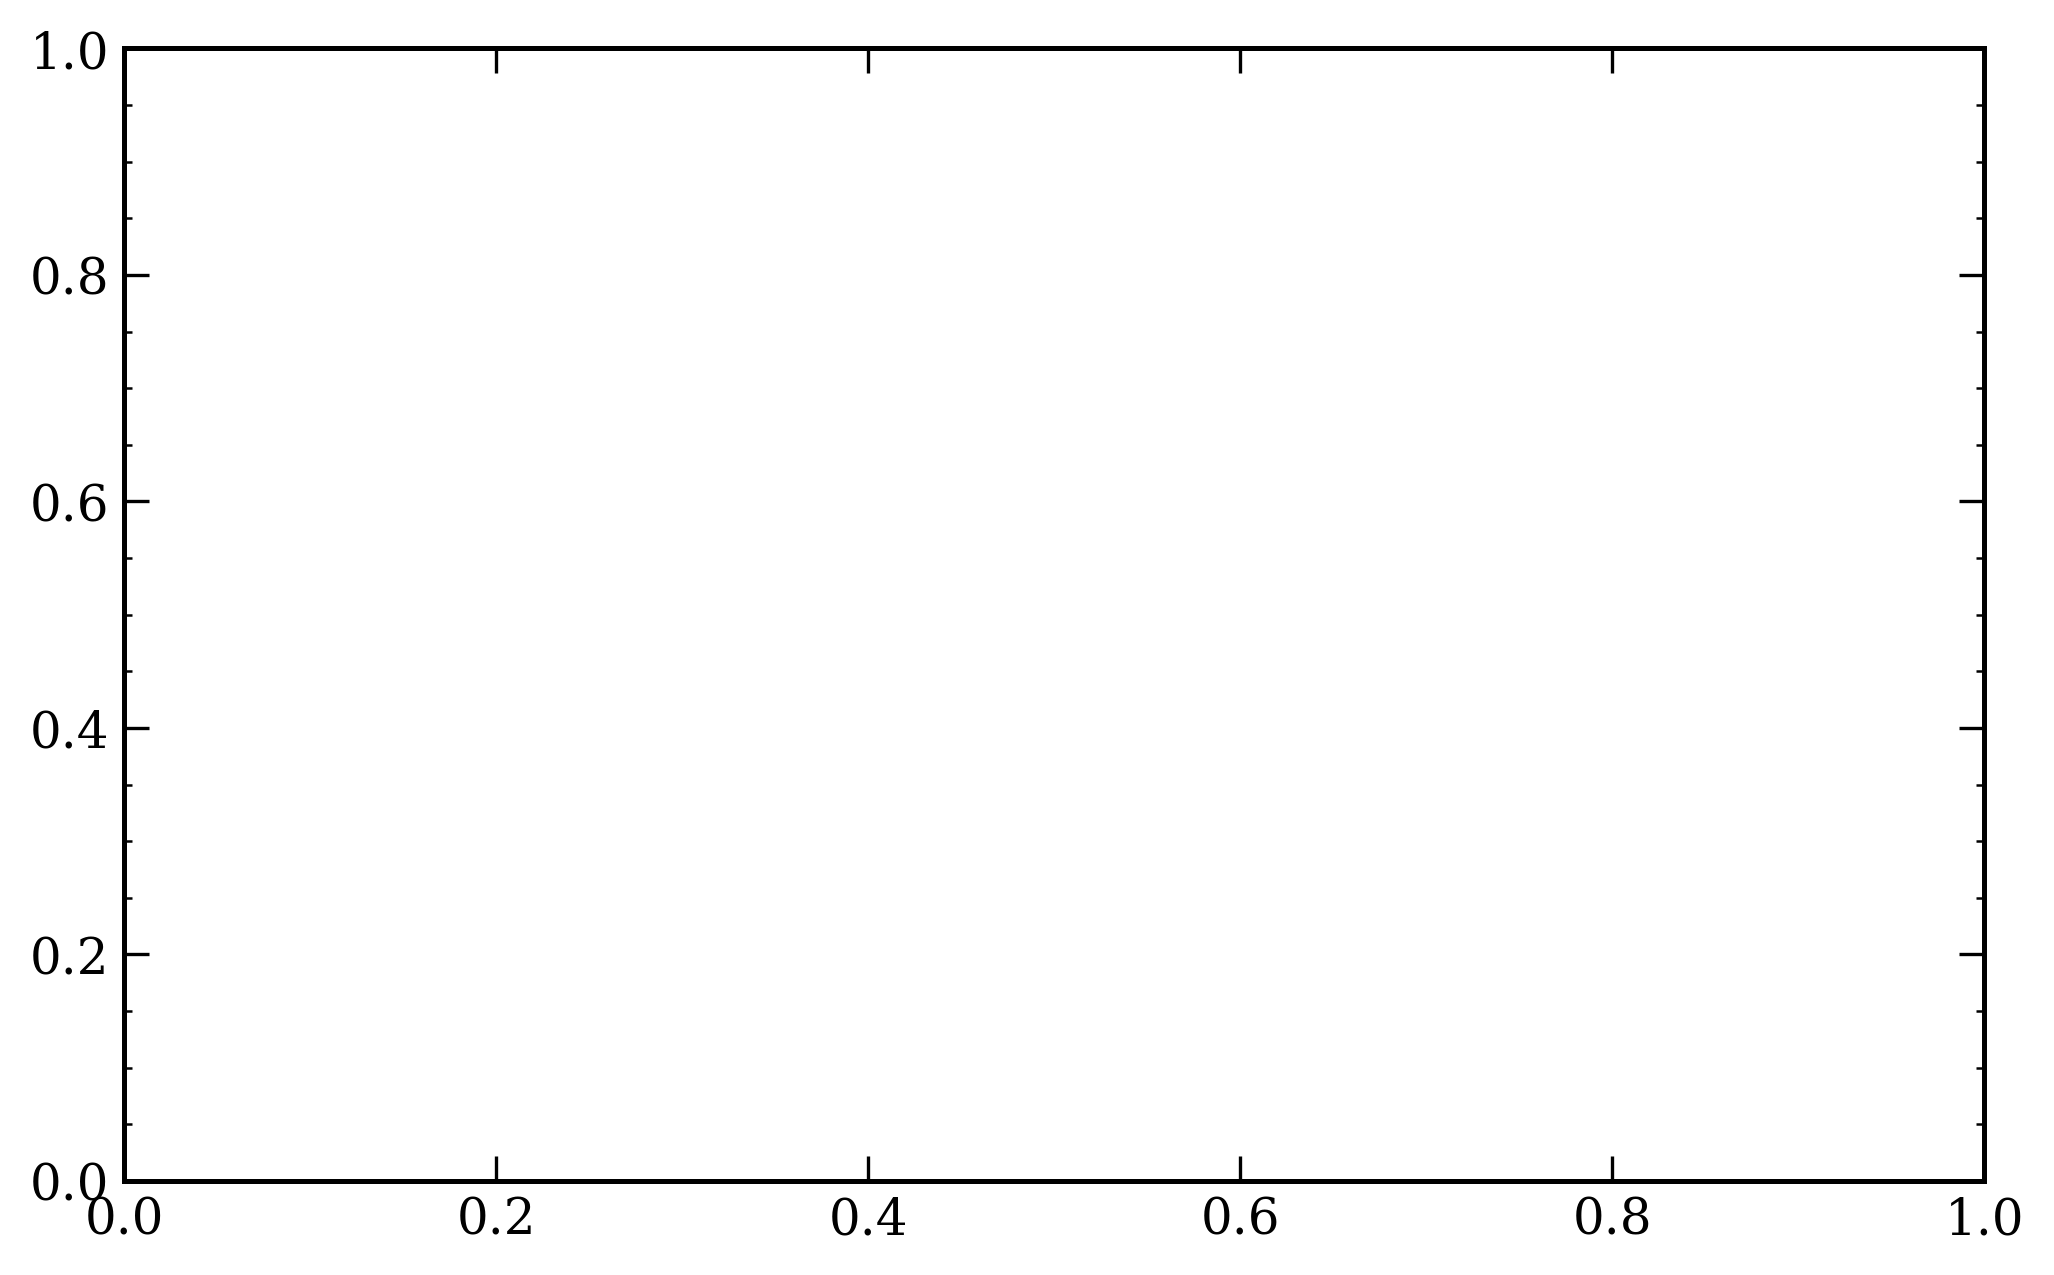

In [23]:
# --- 2. JOURNAL FORMATTING PARAMETERS ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.visible': False,
    'ytick.minor.visible': True,
    'legend.frameon': False,
    'legend.fontsize': 10
})

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

x = np.arange(len(df_w1_sr_results['Feature']))
width = 0.25

# Publication-safe colors (Wong palette)
colors = ['#0072B2', '#D55E00', '#009E73']

# --- 3. PLOTTING BARS ---
ax.bar(x - width, df_w1_sr_results['Gen'], width, label='Gen', color=colors[0], edgecolor='black', linewidth=1)
ax.bar(x,         df_w1_sr_results['RW'],  width, label='RW',  color=colors[1], edgecolor='black', linewidth=1)
ax.bar(x + width, df_w1_sr_results['Nom'], width, label='Nom', color=colors[2], edgecolor='black', linewidth=1)

# --- 4. LABELS AND FORMATTING ---
ax.set_ylabel(r'$W_{1}$ Distance')

# Log scale for values that span multiple orders of magnitude
ax.set_yscale('log')
ax.set_ylim(1e-4, 2e-1) 

# LaTeX formatted ticks for physics/ML nomenclature
label_map = {
    'met_recalc_pt': r'$p_{T}^{miss}$',
    'ht': r'$H_{T}$',
    'ljet1_tau21': r'ljet1 $\tau_{21}$',
    'ljet1_tau32': r'ljet1 $\tau_{32}$',
    'ljet2_tau21': r'ljet2 $\tau_{21}$',
    'ljet2_tau32': r'ljet2 $\tau_{32}$',
    'mjj': r'$m_{jj}$'
}

ax.set_xticks(x)
ax.set_xticklabels([label_map.get(f, f) for f in df_w1_sr_results['Feature']], rotation=45, ha='right')

ax.legend(loc='upper right')

# --- 5. EXPORT ---
plt.tight_layout()
# plt.savefig('w1_sr_results.pdf', format='pdf', bbox_inches='tight')
plt.show()

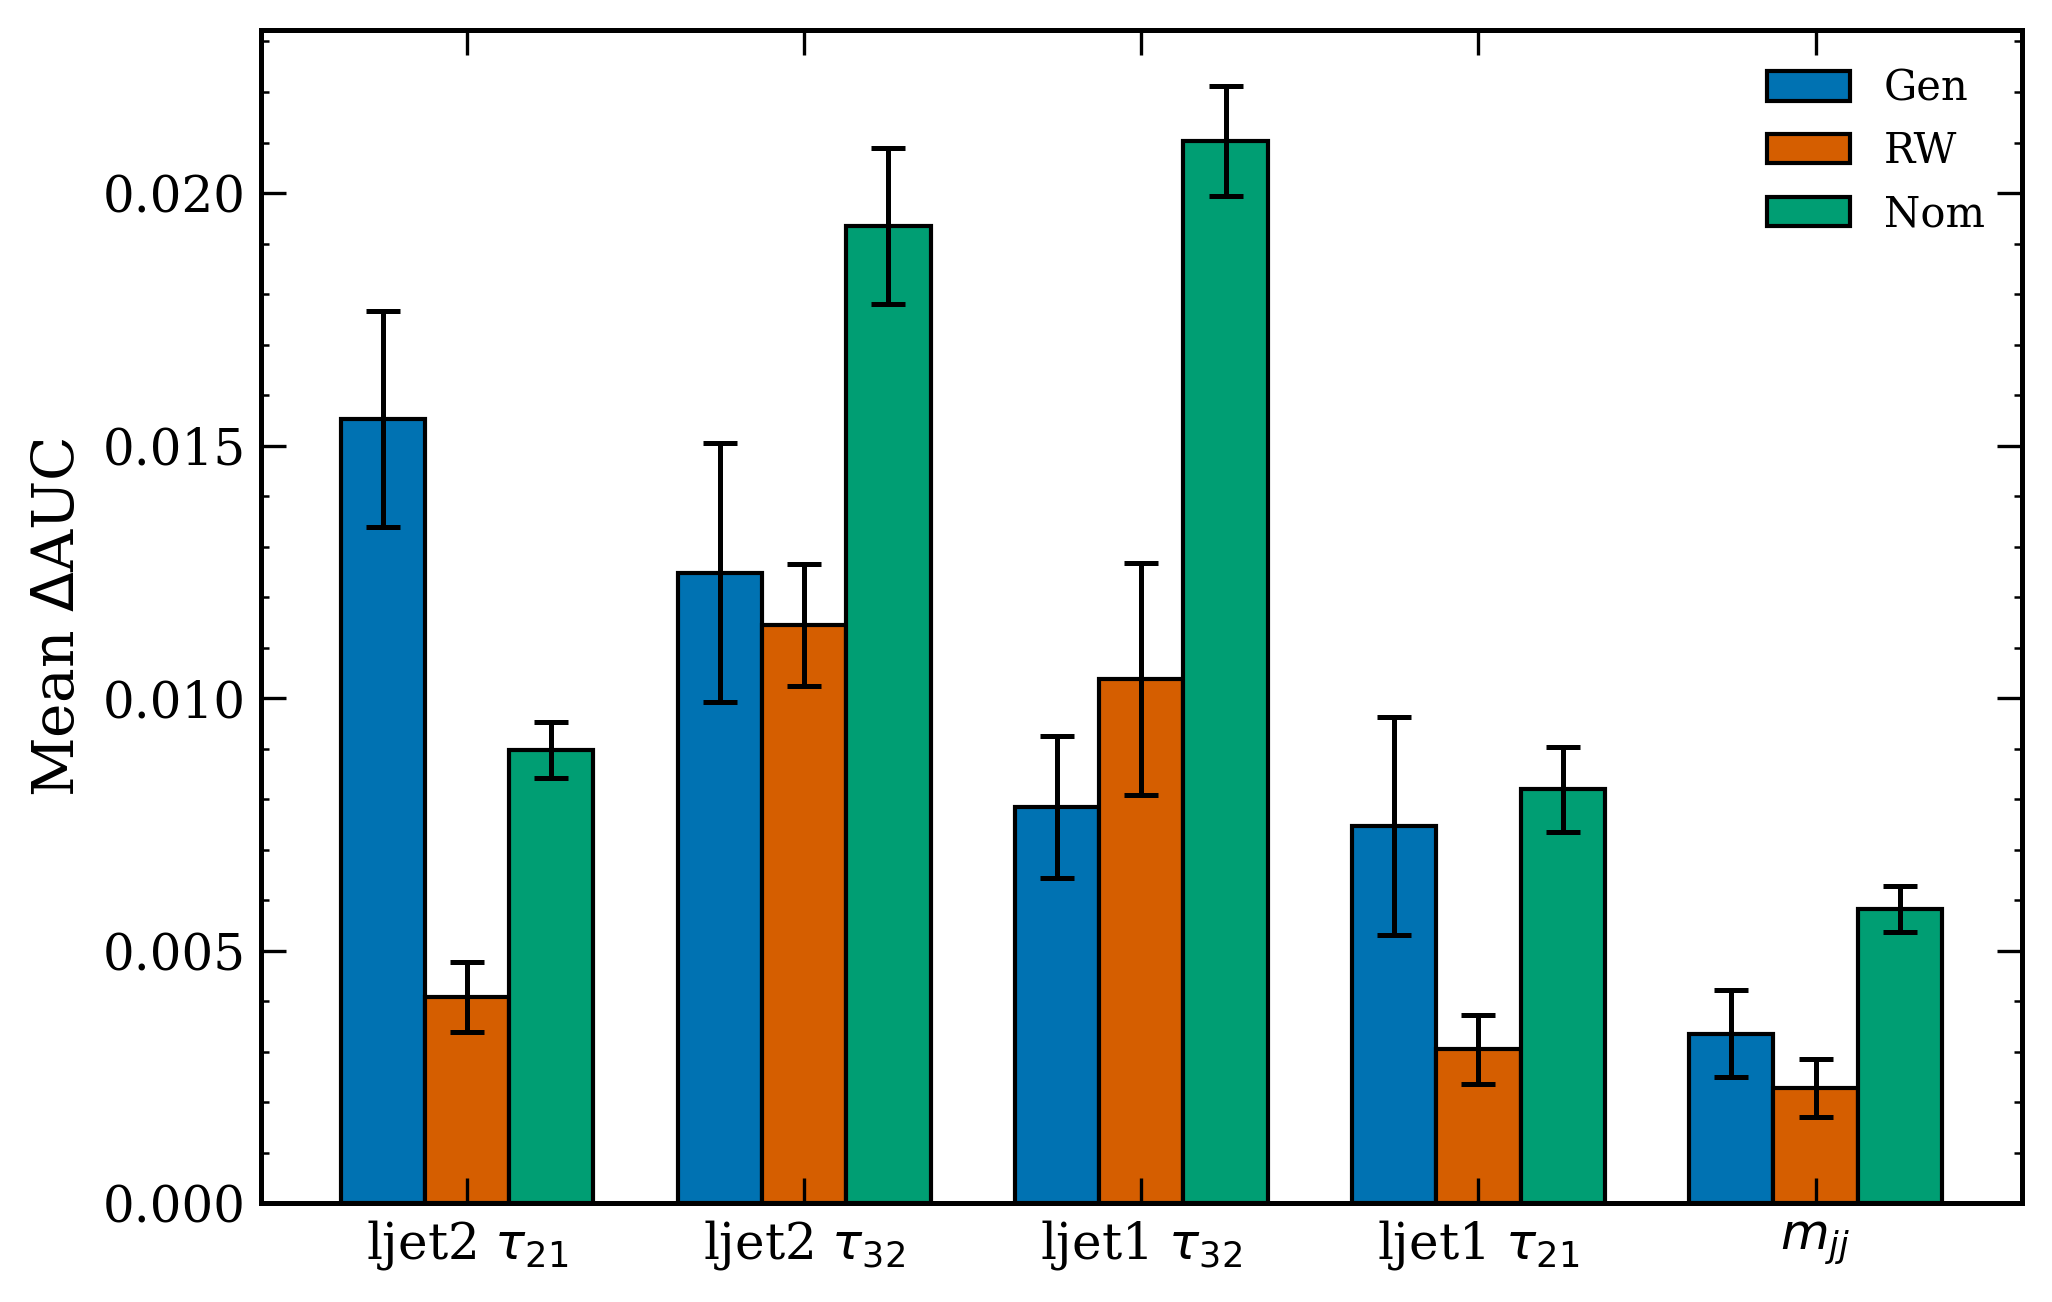

In [14]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.visible': False,
    'ytick.minor.visible': True,
    'legend.frameon': False,
    'legend.fontsize': 10
})

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

x = np.arange(len(df_importances_results['Feature']))
width = 0.25

# Publication-safe colors (high contrast, colorblind friendly)
colors = ['#0072B2', '#D55E00', '#009E73'] 

# --- Plotting ---
ax.bar(x - width, df_importances_results['Mean_AUC_Drop_Gen'], width, yerr=df_importances_results['Std_AUC_Drop_Gen'], 
       label='Gen', color=colors[0], edgecolor='black', linewidth=1,
       error_kw=dict(lw=1.2, capsize=4, capthick=1.2, ecolor='black'))
       
ax.bar(x, df_importances_results['Mean_AUC_Drop_RW'], width, yerr=df_importances_results['Std_AUC_Drop_RW'], 
       label='RW', color=colors[1], edgecolor='black', linewidth=1,
       error_kw=dict(lw=1.2, capsize=4, capthick=1.2, ecolor='black'))
       
ax.bar(x + width, df_importances_results['Mean_AUC_Drop_Nom'], width, yerr=df_importances_results['Std_AUC_Drop_Nom'], 
       label='Nom', color=colors[2], edgecolor='black', linewidth=1,
       error_kw=dict(lw=1.2, capsize=4, capthick=1.2, ecolor='black'))

# --- Labels and Formatting ---
ax.set_ylabel(r'Mean $\Delta$AUC')

# LaTeX formatted ticks for physics/ML nomenclature
label_map = {
    'ljet2_tau21': r'ljet2 $\tau_{21}$',
    'ljet2_tau32': r'ljet2 $\tau_{32}$',
    'ljet1_tau32': r'ljet1 $\tau_{32}$',
    'ljet1_tau21': r'ljet1 $\tau_{21}$',
    'mjj': r'$m_{jj}$'
}
ax.set_xticks(x)
ax.set_xticklabels([label_map.get(f, f) for f in df_importances_results['Feature']])

# Legend
ax.legend(loc='upper right')

# Save directly to high-res PDF for LaTeX imports
plt.tight_layout()
# plt.savefig('feature_importance.pdf', format='pdf', bbox_inches='tight')
plt.show()

=== Joint Distribution Validation ===
Mean Absolute Error of Correlations: 0.0133
Conclusion: Excellent structural fidelity.


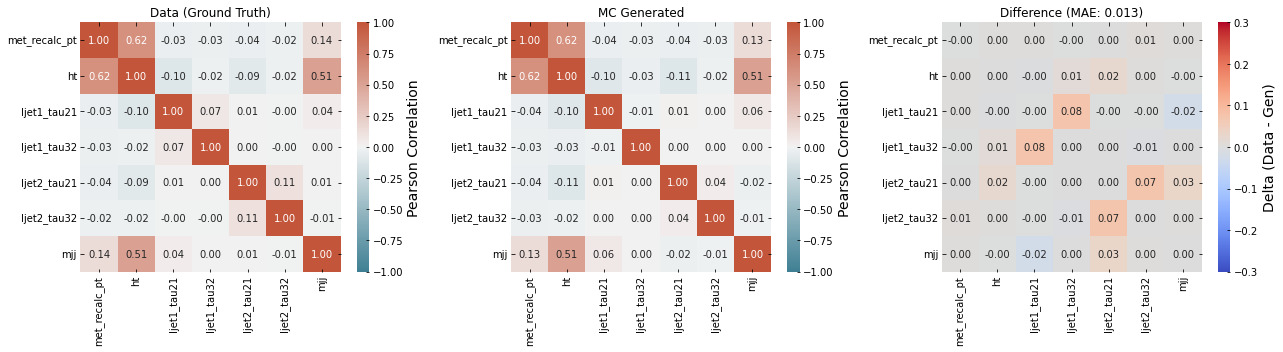

=== Joint Distribution Validation ===
Mean Absolute Error of Correlations: 0.0075
Conclusion: Excellent structural fidelity.


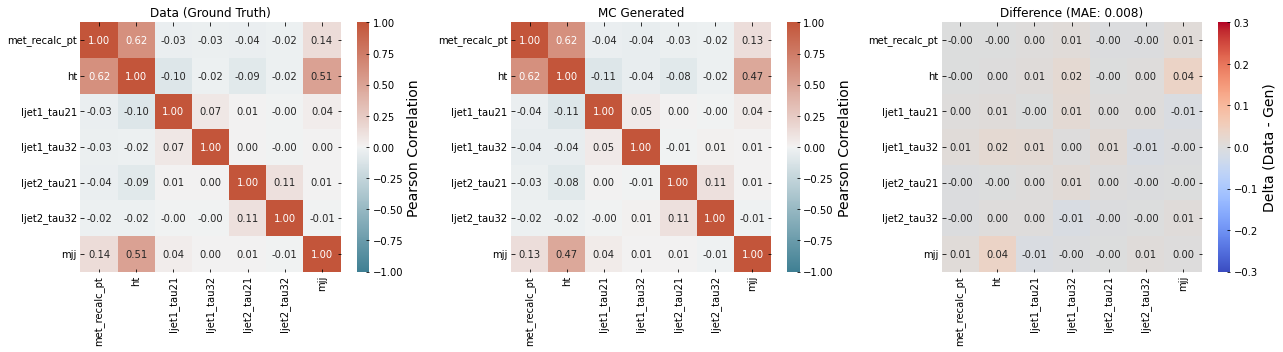

In [10]:
evaluate_correlations(df_data_scoring, df_mc_gen_scoring, context_vars + features_vars, GEN_WEIGHT_COL)
evaluate_correlations(df_data_scoring, df_mc_rw_scoring, context_vars + features_vars, RW_WEIGHT_COL)

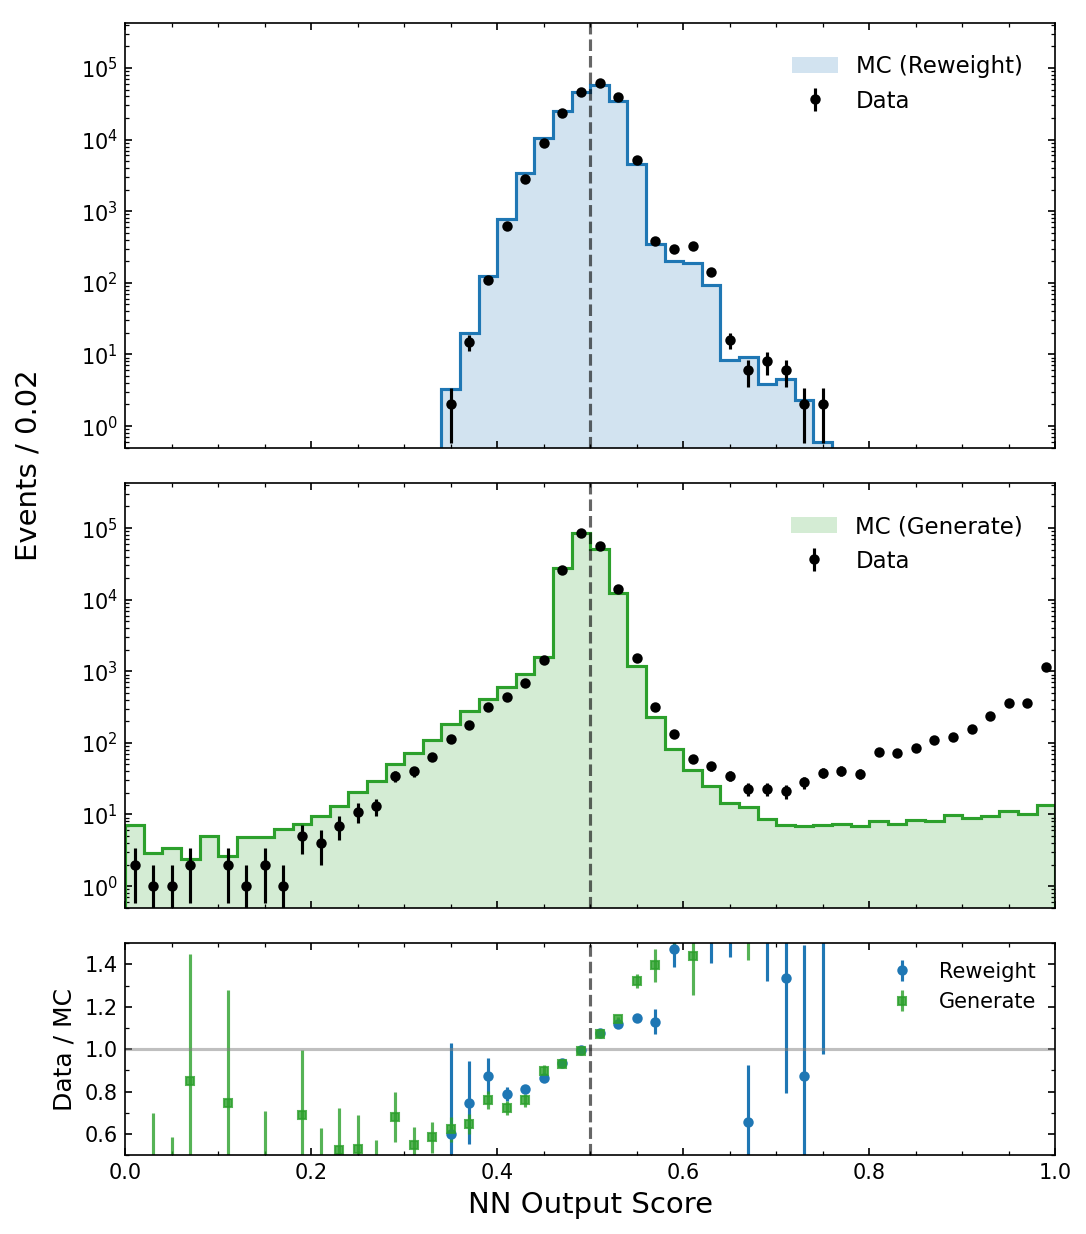

In [7]:
from matplotlib import gridspec
import matplotlib.ticker as ticker

RW_Scores = df_mc_rw_scoring["rw_score"]
RW_weights = df_mc_rw_scoring["rw_median_weights"]
RW_Data_Scores = df_data_scoring["data_score_rw"]

GEN_Scores = df_mc_gen_scoring["gen_score"]
GEN_weights = df_mc_gen_scoring["total_weight"]
GEN_Data_Scores = df_data_scoring["data_score_gen"]

def get_events_hist_and_err(data, bins, weights=None):
    counts, _ = np.histogram(data, bins=bins, weights=weights)
    if weights is None:
        err2 = counts
    else:
        err2, _ = np.histogram(data, bins=bins, weights=weights**2)
    err = np.sqrt(err2)
    return counts, err

# ==============================================================================
# 3. HEP Style Setup & Layout (Stacked Vertical)
# ==============================================================================
plt.style.use('default')
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "lines.linewidth": 1.5,
    "legend.frameon": False,
    "legend.fontsize": 11
})

bins = np.linspace(0.0, 1.0, 51)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Adjusted figure size for vertical stacking
fig = plt.figure(figsize=(8, 10), dpi=150)

# 3 Rows, 1 Column: Top (Main 1), Middle (Main 2), Bottom (Combined Ratio)
gs = gridspec.GridSpec(3, 1, height_ratios=[3, 3, 1.5], hspace=0.1)

ax0_main = fig.add_subplot(gs[0])
# Share X and Y axes for the main plots so they are directly comparable
ax1_main = fig.add_subplot(gs[1], sharex=ax0_main, sharey=ax0_main) 
ax_ratio = fig.add_subplot(gs[2], sharex=ax0_main)

# ==============================================================================
# 4. Plot 1: Reweighted Model vs Data (Top Pad)
# ==============================================================================
rw_mc_counts, rw_mc_err = get_events_hist_and_err(RW_Scores, bins, RW_weights)
rw_data_counts, rw_data_err = get_events_hist_and_err(RW_Data_Scores, bins)

ax0_main.hist(bins[:-1], bins=bins, weights=rw_mc_counts, histtype="stepfilled", 
              alpha=0.2, color="tab:blue", label="MC (Reweight)")
ax0_main.hist(bins[:-1], bins=bins, weights=rw_mc_counts, histtype="step", 
              color="tab:blue", linewidth=1.5)
ax0_main.errorbar(bin_centers, rw_data_counts, yerr=rw_data_err, fmt='ko', 
                  markersize=4, capsize=0, label="Data")

with np.errstate(divide='ignore', invalid='ignore'):
    ratio_rw = rw_data_counts / rw_mc_counts
    ratio_rw_err = rw_data_err / rw_mc_counts

# ==============================================================================
# 5. Plot 2: Generative Model vs Data (Middle Pad)
# ==============================================================================
gen_mc_counts, gen_mc_err = get_events_hist_and_err(GEN_Scores, bins, GEN_weights)
gen_data_counts, gen_data_err = get_events_hist_and_err(GEN_Data_Scores, bins)

ax1_main.hist(bins[:-1], bins=bins, weights=gen_mc_counts, histtype="stepfilled", 
              alpha=0.2, color="tab:green", label="MC (Generate)")
ax1_main.hist(bins[:-1], bins=bins, weights=gen_mc_counts, histtype="step", 
              color="tab:green", linewidth=1.5)
ax1_main.errorbar(bin_centers, gen_data_counts, yerr=gen_data_err, fmt='ko', 
                  markersize=4, capsize=0, label="Data")

with np.errstate(divide='ignore', invalid='ignore'):
    ratio_gen = gen_data_counts / gen_mc_counts
    ratio_gen_err = gen_data_err / gen_mc_counts

# ==============================================================================
# 6. Combined Ratio Plot (Bottom Pad)
# ==============================================================================
# Plot Reweighted Ratio (Blue dots)
ax_ratio.errorbar(bin_centers, ratio_rw, yerr=ratio_rw_err, fmt='o', 
                  color='tab:blue', markersize=4, capsize=0, label='Reweight')

# Plot Generative Ratio (Green squares to distinguish from dots)
ax_ratio.errorbar(bin_centers, ratio_gen, yerr=ratio_gen_err, fmt='s', 
                  color='tab:green', markersize=4, capsize=0, alpha=0.8, label='Generate')

# ==============================================================================
# 7. Formatting & Aesthetics
# ==============================================================================
for ax in [ax0_main, ax1_main]:
    ax.set_yscale("log")
    ax.set_xlim(0, 1)
    # ax.set_ylabel(f"Events / {bin_width:.2f}")
    
    # Calculate global limits across both datasets so the shared Y-axis fits everything
    valid_mc = np.concatenate([rw_mc_counts[rw_mc_counts > 0], gen_mc_counts[gen_mc_counts > 0]])
    valid_data = np.concatenate([rw_data_counts[rw_data_counts > 0], gen_data_counts[gen_data_counts > 0]])
    ymin = max(min(valid_mc.min() if len(valid_mc) else 1, 
                   valid_data.min() if len(valid_data) else 1) * 0.5, 0.5)
    ymax = max(rw_data_counts.max(), gen_data_counts.max()) * 5
    ax.set_ylim(ymin, ymax)
            
    ax.legend(loc="upper right", borderaxespad=1.0)
    ax.minorticks_on()
    
    # Add vertical dashed line at 0.5
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.6)
    
    # Hide X-axis tick labels for main plots (since they are stacked above the ratio)
    plt.setp(ax.get_xticklabels(), visible=False)

# Format the Combined Ratio plot
ax_ratio.set_xlim(0, 1)
ax_ratio.set_ylim(0.5, 1.5)
ax_ratio.set_ylabel("Data / MC", fontsize=12)
ax_ratio.set_xlabel("NN Output Score")
ax_ratio.axhline(1.0, color='gray', linestyle='-', alpha=0.5)
ax_ratio.axvline(0.5, color='black', linestyle='--', alpha=0.6)
ax_ratio.minorticks_on()
# Create an invisible axis spanning the top two main plots (rows 0 and 1)
ax_common_y = fig.add_subplot(gs[0:2], frameon=False)

# Hide ticks and tick labels for the invisible axis
ax_common_y.tick_params(labelcolor='none', which='both', 
                        top=False, bottom=False, left=False, right=False)

# Set the single centered Y-axis label
ax_common_y.set_ylabel(f"Events / {bin_width:.2f}", fontsize=14, labelpad=20)
# Clean up ratio y-ticks
ax_ratio.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax_ratio.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
yticks = ax_ratio.yaxis.get_major_ticks()
if len(yticks) > 0:
    yticks[-1].label1.set_visible(False) # Prevent top label overlapping

# Add legend to the combined ratio plot
ax_ratio.legend(loc="upper right", ncol=1, frameon=False, fontsize=10)
plt.savefig("Results/Bkg_scores.pdf")
plt.show()